# Setting

In [1]:
import pandas as pd
from datetime import datetime

# 買進賣出需要的手續費
fee = {
    "tax_stock": 0.003,  # 賣出0.003
    "tax_future": 0.00002 * 2,  # 買進與賣出各0.00002
    "fee_stock": 0.001425 * 2,  # 券商手續費公道價，買進與賣出各0.001425
    "fee_future": 0.00002 * 2,  # 各家不大相同，以交易稅計算
    "sliding_price": 0.00001,  # 滑價
}

# 股票清單
tw_index_fee = 0
tw_stock_fee = 0
# tw_stock_fee = fee["tax_stock"] + fee["fee_stock"] + fee["sliding_price"]
# tw_index_fee = fee["tax_future"] + fee["fee_future"] + fee["sliding_price"]

data = [
    # ["2308", "台達電", "tw", tw_stock_fee],
    # ["2317", "鴻海", "tw", tw_stock_fee],
    # ["2330", "台積電", "tw"],
    # ["2382", "廣達", "tw", tw_stock_fee],
    # ["2412", "中華電", "tw", tw_stock_fee],
    # ["2454", "聯發科", "tw", tw_stock_fee],
    # ["2881", "富邦金", "tw", tw_stock_fee],
    # ["2882", "國泰金", "tw", tw_stock_fee],
    # ["2891", "中信金", "tw", tw_stock_fee],
    # ["6505", "台塑化", "tw", tw_stock_fee],
    
    # ["3231", "緯創", "tw", tw_stock_fee],
    # ["2207", "和泰車", "tw", tw_stock_fee],
    # ["3661", "世芯", "tw", tw_stock_fee],
    # ["2603", "長榮", "tw", tw_stock_fee],
    # ["2408", "南亞科", "tw", tw_stock_fee],
    
    
    ["AAPL", "Apple Inc.", "us"],
    ["MSFT", "Microsoft", "us"],
    ["NVDA", "Nvidia", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["META", "Meta Platforms", "us"],
    ["GOOGL", "Google", "us"],
    ["TSLA", "Tesla", "us"],
    ["AVGO", "Broadcom", "us"],
    ["BRK", "Berkshire Hathaway", "us"],
    ["JPM", "JPMorgan Chase", "us"],
    
    ["BA", "Boeing", "us"],
    ["MRNA", "Moderna", "us"],
    ["WMT", "Walmart", "us"],
    ["UNH", "UnitedHealth Group", "us"],
    ["DIS", "Disney", "us"],
    
    ["INTC", "Intel", "us"],
    ["CSCO", "Cisco", "us"],
    ["CVX", "Chevron", "us"],
    ["PG", "Procter & Gamble", "us"],
    ["HD", "Home Depot", "us"],
]

# 指數
index_twii = [
    ["2308", "台達電", "tw"],
    ["2317", "鴻海", "tw"],
    ["2330", "台積電", "tw"],
    ["2382", "廣達", "tw"],
    ["2412", "中華電", "tw"],
    ["2454", "聯發科", "tw"],
    ["2881", "富邦金", "tw"],
    ["2882", "國泰金", "tw"],
    ["2891", "中信金", "tw"],
    ["6505", "台塑化", "tw"],
]

index_spx = [
    ["AAPL", "Apple Inc.", "us"],
    ["MSFT", "Microsoft", "us"],
    ["NVDA", "Nvidia", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["META", "Meta Platforms", "us"],
    ["GOOGL", "Google", "us"],
    ["TSLA", "Tesla", "us"],
    ["AVGO", "Broadcom", "us"],
    ["BRK", "Berkshire Hathaway", "us"],
    ["JPM", "JPMorgan Chase", "us"],
]

market_index = [
    ["twii", "台灣指數期貨", "tw", index_twii, tw_index_fee],
    ["spx", "S&P 500", "us", index_spx],
]

date_ranges = [
    ["20210401", "20220331", "2022Q1"], # 2022
    ["20210701", "20220630", "2022Q2"],
    ["20211001", "20220930", "2022Q3"],
    ["20220101", "20221231", "2022Q4"],
    ["20220401", "20230331", "2023Q1"], # 2023
    ["20220701", "20230630", "2023Q2"],
    ["20221001", "20230930", "2023Q3"],
    ["20230101", "20231231", "2023Q4"],
    ["20230401", "20240331", "2024Q1"], # 2024
    ["20230701", "20240630", "2024Q2"],
    ["20231001", "20240930", "2024Q3"],
    ["20240101", "20241231", "2024Q4"],
    
    # ["20240101", "20240115", "test"],
    # ["20231001", "20240131", "2024M1"],
    # ["20231101", "20240229", "2024M2"],
    # ["20231201", "20240331", "2024M3"],
    # ["20240101", "20240430", "2024M4"],
    # ["20240201", "20240531", "2024M5"],
    # ["20240301", "20240630", "2024M6"],
    # ["20240401", "20240731", "2024M7"],
    # ["20240501", "20240831", "2024M8"],
    # ["20240601", "20240930", "2024M9"],
    # ["20240701", "20241031", "2024M10"],
    # ["20240801", "20241130", "2024M11"],
    # ["20240901", "20241231", "2024M12"],
]

# env = {
#     "stock_id" : "NVDA",
#     "stock_name" : "Nvidia",
#     "country" : "us",
#     "start_date" : "20230401",
#     "end_date" : "20240331",
# }

# On(Over Night)抱股過夜作法，正面就持續持有，負面就賣出
# Usable Factor 只跑有用的factor

In [2]:
def get_balance_list(list_rtn, start_price):
    balance = start_price
    list_balance = []
    for rtn in list_rtn:
        balance = balance * (1 + float(rtn))
        list_balance.append(balance)
    return list_balance

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from math import ceil, sqrt

def display_all_plots(all_plots):
    # 計算需要的子圖行數與列數（接近正方形排列）
    num_plots = len(all_plots)
    cols = ceil(sqrt(num_plots))  # 列數
    rows = ceil(num_plots / cols)  # 行數

    # 創建一個大的畫布
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    # fig.suptitle("Trading Results for All Stocks", fontsize=16, y=0.95)

    # 確保 axes 是一個 2D 陣列
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1 or cols == 1:
        axes = [axes] if rows == 1 else [[ax] for ax in axes]
    else:
        axes = axes.reshape(rows, cols)

    # 在每個子圖中顯示單獨的圖表
    for idx, single_fig in enumerate(all_plots):
        row, col = divmod(idx, cols)
        ax = axes[row][col]
        
        # 從單個圖表中提取並繪製數據
        for line in single_fig.axes[0].get_lines():
            ax.plot(line.get_xdata(), line.get_ydata(), label=line.get_label())
        
        # 設定標題、標籤與圖例
        ax.set_title(single_fig.axes[0].get_title())
        ax.set_xlabel(single_fig.axes[0].get_xlabel())
        ax.set_ylabel(single_fig.axes[0].get_ylabel())
        ax.legend()
        
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # 設置最多顯示 5 個標籤


    # 移除多餘的空白子圖
    for idx in range(num_plots, rows * cols):
        row, col = divmod(idx, cols)
        fig.delaxes(axes[row][col])

    # 調整整體佈局
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)  # 調整總標題的位置
    plt.show()

In [4]:
def cacl_avg(df_stocks_results, wincount=None, ttl_count=None):
    '''
        only return average row
    '''
    
    average_row = pd.DataFrame()
    average_row['tp'] = [df_stocks_results['tp'].sum()]
    average_row['fp'] = [df_stocks_results['fp'].sum()]
    average_row['tn'] = [df_stocks_results['tn'].sum()]
    average_row['fn'] = [df_stocks_results['fn'].sum()]
    average_row['accuracy'] = (average_row['tp'] + average_row['tn']) / (average_row['tp'] + average_row['tn'] + average_row['fp'] + average_row['fn'])
    average_row['precision'] = average_row['tp'] / (average_row['tp'] + average_row['fp'])
    # EV 算法 每個ev成上avail_count 總和後再除上 avail_count 的平均
    average_row['avail_count'] = [df_stocks_results['avail_count'].sum()]
    average_row['pci_avl_count'] = [df_stocks_results['tp'].sum() + df_stocks_results['fp'].sum()]
    average_row['ev'] = (df_stocks_results['ev'].astype(float) * df_stocks_results['avail_count']).sum() / df_stocks_results['avail_count'].sum()
    average_row['precision_ev'] = (df_stocks_results['precision_ev'].astype(float) * (df_stocks_results['tp'] + df_stocks_results['fp'])).sum() / (df_stocks_results['tp'].sum() + df_stocks_results['fp'].sum())
    if ttl_count is None:
        average_row['win B&H'] = None
    else:
        average_row['win B&H'] = round(wincount / ttl_count, 2)
    
    return average_row

In [5]:
# from factor_overnight import FactorON
# for stock in data:
#     env = {
#         "stock_id" : stock[0],
#         "stock_name" : stock[1],
#         "country" : stock[2],
#         "start_date" : "20230401",
#         "end_date" : "20240331",
#         "run_count": "1"
#     }
#     print(env['stock_id'], env['stock_name'], env['country'])

#     eval_module = FactorON(env)
#     eval_module.show_individual(mode=1)
    

In [6]:
# from usable_on import UsableFactorON

# for stock in data:
#     env = {
#         "stock_id" : stock[0],
#         "stock_name" : stock[1],
#         "country" : stock[2],
#         "start_date" : "20230401",
#         "end_date" : "20240331",
#         "run_count": "1"
#     }
#     print(env['stock_id'], env['stock_name'], env['country'])

#     eval_module = UsableFactorON(env)
#     print(eval_module.get_individual(mode=1))
#     a = eval_module.show_sig() 

In [7]:
# # Delete folders named "spx" in the directory tree
# import os
# import shutil

# # Set the root directory for the project
# root_dir = r"/Users/yanyifu/Documents/_Coding/LLM Predict Stock/run_factor/out_stock/Training_result/FactorUsableMix"

# # Walk the directory tree and delete folders named "spx"
# for dirpath, dirnames, filenames in os.walk(root_dir, topdown=False):
#     for dirname in dirnames:
#         if dirname.lower() == "twii":
#             full_path = os.path.join(dirpath, dirname)
#             print(f"Deleting folder: {full_path}")
#             shutil.rmtree(full_path)

In [8]:
from factor_overnight_index import FactorON_Index
from usable_on_index import Index_UsableFactorON

for stock in market_index:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20240101",
        "end_date" : "20241231",
        "run_count": "1"
    }
    print(env['stock_id'], env['stock_name'], env['country'])

    eval_module = Index_UsableFactorON(env)
    # print(eval_module.get_individual(mode=1))
    a = eval_module.show_sig()

twii 台灣指數期貨 tw
  20210401 =>   1   1   1   1   1   1   1   1 
  20210406 =>   1   1   1  -1   1   1   1   1 
  20210407 =>   1   1   1   1   1   1   1   0 
  20210408 =>   1   1   1   1   1   1   1   1 
  20210409 =>   1   1   1   1   1   0  -1  -1 
  20210412 =>   0   0  -1  -1   1   1  -1  -1 
  20210413 =>   1   0   1  -1   1   1  -1  -1 
  20210414 =>   1   1   1  -1   1   1  -1  -1 
  20210415 =>   0   1   1   1   1   1   0  -1 
  20210416 =>   1   1   1  -1   1   1  -1   0 
  20210419 =>   1   0   1   1   1   1   0   1 
  20210420 =>   1   1   1  -1   1   1  -1   1 
  20210421 =>   1   0   1   1   0   1  -1   1 
  20210422 =>   1  -1   1   0   1   1  -1  -1 
  20210423 =>   1   1   1  -1   1   1  -1  -1 
  20210426 =>   0   0   0   0   0   0   0   0 
  20210427 =>   1   1   1   1   1   1   1   1 
  20210428 =>   1   1   1  -1   1   1  -1  -1 
  20210429 =>   1   1   1   1   1   1   1  -1 
  20210503 =>   1   1   1  -1   1   1   1   0 
  20210504 =>   1   1   1   1   1   1   1  -1

# 7-6 統計Factors 全選

1
twii 台灣指數期貨 tw 2022Q1
twii 台灣指數期貨 tw 2022Q2
twii 台灣指數期貨 tw 2022Q3
twii 台灣指數期貨 tw 2022Q4
twii 台灣指數期貨 tw 2023Q1
twii 台灣指數期貨 tw 2023Q2
twii 台灣指數期貨 tw 2023Q3
twii 台灣指數期貨 tw 2023Q4
twii 台灣指數期貨 tw 2024Q1
twii 台灣指數期貨 tw 2024Q2
twii 台灣指數期貨 tw 2024Q3
twii 台灣指數期貨 tw 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
0,0.561404,0.568627,0.000054,-0.000221,57,29,22,3,3,NaN
1,0.370968,0.340000,-0.002811,-0.003134,62,17,33,6,6,NaN
2,0.476923,0.481481,-0.000531,-0.000988,65,26,28,5,6,NaN
3,0.468750,0.519231,-0.000706,-0.000223,64,27,25,3,9,NaN
4,0.600000,0.600000,0.000932,0.001026,55,30,20,3,2,NaN
5,0.650000,0.647059,0.000958,0.000786,60,33,18,6,3,NaN
6,0.587302,0.580000,0.001171,0.000369,63,29,21,8,5,NaN
7,0.634921,0.739130,0.001566,0.001854,63,34,12,6,11,NaN
8,0.607143,0.590909,0.002385,0.002026,56,26,18,8,4,NaN
9,0.639344,0.640000,0.002903,0.002362,61,32,18,7,4,NaN


spx S&P 500 us 2022Q1
spx S&P 500 us 2022Q2
spx S&P 500 us 2022Q3
spx S&P 500 us 2022Q4
spx S&P 500 us 2023Q1
spx S&P 500 us 2023Q2
spx S&P 500 us 2023Q3
spx S&P 500 us 2023Q4
spx S&P 500 us 2024Q1
spx S&P 500 us 2024Q2
spx S&P 500 us 2024Q3
spx S&P 500 us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
0,0.500000,0.483871,-0.000076,-0.000350,64,30,32,2,0,NaN
1,0.365079,0.377358,-0.002786,-0.002930,63,20,33,3,7,NaN
2,0.515625,0.516129,0.000262,0.000181,64,32,30,1,1,NaN
3,0.428571,0.436364,-0.000532,0.000094,63,24,31,3,5,NaN
4,0.555556,0.557377,0.001165,0.001309,63,34,27,1,1,NaN
5,0.507937,0.507937,0.001295,0.001295,63,32,31,0,0,NaN
6,0.492063,0.516667,-0.001401,-0.001180,63,31,29,0,3,NaN
7,0.634921,0.666667,0.001448,0.001496,63,38,19,2,4,NaN
8,0.590164,0.568627,0.001585,0.001561,61,29,22,7,3,NaN
9,0.571429,0.559322,-0.000272,-0.000265,63,33,26,3,1,NaN


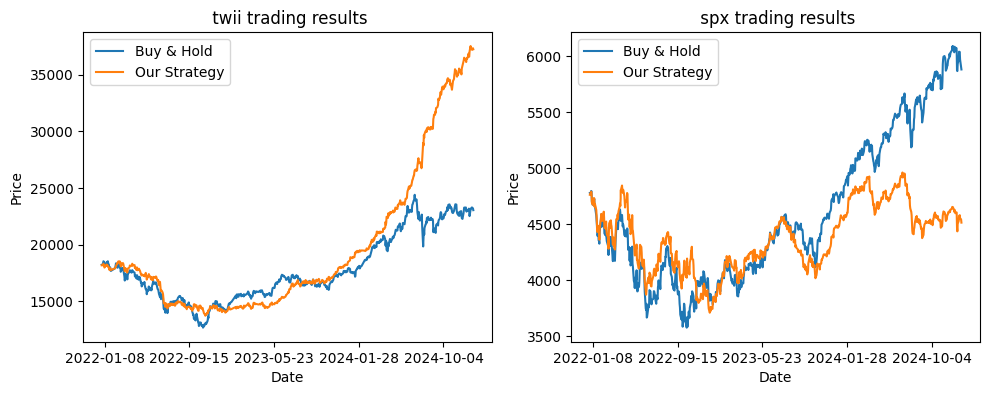

,accuracy,precision,ev,precision_ev,win B&H
第1次,54.26%,54.40%,0.000479,0.000298,0.5
總和,54.26%,54.40%,0.000479,0.000298,0.5


In [9]:
from usable_mix_index_statictic import Index_UsableFactorMix_Statictic

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in market_index:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "components" : stock[3],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i),
                # "fee": stock[4]
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = Index_UsableFactorMix_Statictic(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
        # show stock results
        df_stock = pd.DataFrame(list_stock).loc[:, selected_columns]
        stock_avg = cacl_avg(df_stock)
        stock_avg.index = [stock[0]]
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_rtn[-1] else "no"
        stock_avg = pd.concat([df_stock, stock_avg])
        display(stock_avg.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn', 'win B&H']])
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])